In [100]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#### ANALISIS LIBLARY

#### Pengolahan Data & File System
* os: Digunakan untuk berinteraksi dengan sistem operasi, terutama untuk membaca direktori (folder) dataset dan mendapatkan jalur (path) file gambar.

* numpy (np): Pustaka dasar untuk komputasi numerik. Digunakan untuk memanipulasi array gambar, melakukan operasi matematika pada piksel, dan menyimpan data fitur.

* pandas (pd): Digunakan untuk mengelola data dalam bentuk tabel (Dataframe). Berguna untuk menyimpan hasil ekstraksi fitur GLCM ke dalam file .csv.

#### Pemrosesan Citra (Image Processing)
* cv2 (cv): Pustaka OpenCV. Digunakan sebagai alat utama untuk memuat gambar, mengubah ruang warna (BGR ke Grayscale), melakukan filter (Median Blur), dan operasi morfologi (Morfologi Opening).

* skimage.feature (graycomatrix, graycoprops): Pustaka Scikit-Image yang khusus digunakan untuk Ekstraksi Fitur Tekstur GLCM. graycomatrix membuat matriks hubungan antar piksel, dan graycoprops menghitung nilai statistik fitur seperti contrast, correlation, dll.

* scipy.stats (entropy): Digunakan untuk menghitung nilai entropy dari matriks GLCM sebagai salah satu fitur tambahan untuk mengukur kompleksitas tekstur citra.

#### Visualisasi Data
* matplotlib.pyplot (plt): Pustaka utama untuk menampilkan hasil visual, baik itu gambar pisang, grafik distribusi, maupun plot hasil evaluasi model.

* seaborn (sns): Pustaka yang dibangun di atas Matplotlib untuk membuat visualisasi statistik yang lebih menarik, terutama digunakan untuk membuat Heatmap korelasi fitur.

#### Machine Learning & Evaluasi
* sklearn.model_selection (train_test_split): Digunakan untuk membagi dataset menjadi dua bagian: data training (untuk melatih model) dan data testing (untuk menguji akurasi model).

* sklearn.ensemble (RandomForestClassifier): Algoritma ensemble berbasis pohon keputusan untuk klasifikasi.

* sklearn.svm (SVC): Algoritma Support Vector Machine yang efektif untuk klasifikasi data berbasis fitur.

* sklearn.neighbors (KNeighborsClassifier): Algoritma K-Nearest Neighbors untuk klasifikasi berbasis kedekatan jarak antar data.

* sklearn.metrics: Pustaka untuk mengevaluasi kinerja model.

* accuracy_score, classification_report: Mengukur performa akurasi, precision, recall, dan f1-score.

* confusion_matrix, ConfusionMatrixDisplay: Digunakan untuk memvisualisasikan matriks kesalahan model (mana kelas yang tertukar).

In [101]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256)) 
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

* Inisialisasi Wadah: * data = [], labels = [], file_name = []: Membuat tiga list kosong untuk menyimpan data gambar, label (nama folder/kelas), dan nama file secara berurutan.

* Perulangan Direktori (os.listdir): * Kode melakukan perulangan untuk mengecek setiap folder yang ada di dalam datasetpisang. os.path.isdir memastikan bahwa yang diproses hanyalah folder, bukan file sampah.

* Membaca Gambar (cv.imread). Di dalam setiap sub-folder, program mencari file dengan ekstensi gambar (.png, .jpg, .jpeg). cv.imread digunakan untuk mengubah file gambar fisik menjadi matriks angka (array) yang dimengerti oleh Python.

* img = img.astype(np.uint8): Memastikan format warna piksel adalah unsigned integer 8-bit (0-255), format standar untuk citra digital.

* Pengecekan Kualitas (if img is not None): * Ini adalah langkah pengamanan (safety check). Jika ada file yang rusak atau bukan gambar, program tidak akan mengalami error, melainkan hanya akan melewati file tersebut.

* Konversi ke Array NumPy: data = np.array(data, dtype=object): Mengubah list menjadi format Array NumPy.

* Penggunaan dtype=object sangat penting di sini karena gambar-gambar dalam dataset mungkin memiliki ukuran (dimensi) yang berbeda-beda. NumPy membutuhkan tipe object agar bisa menampung matriks dengan ukuran yang tidak seragam dalam satu wadah yang sama.

In [102]:
def fungsi_resize(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image

**`fungsi_resize`** fungsi resize gambar manual pakai metode *nearest neighbor*, jadi tanpa `cv.resize`. Logikanya: untuk tiap pixel di gambar baru, dicari posisi yang sepadan di gambar lama berdasarkan rasio ukurannya, terus nilai pixel-nya langsung dicopy ke kanvas baru. Cuma cocok buat gambar grayscale (1 channel) karena kanvas hasilnya dibuat 2D.

In [103]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (256, 256))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

**`baseline`** fungsi preprocessing versi simpel buat pembanding (baseline). Kalau gambarnya masih berwarna (3 channel), diubah ke grayscale dulu, terus diresize ke 256x256. Dipakai sebagai patokan dasar sebelum dibandingkan sama hasil preprocessing yang lebih lengkap.

Cell dibawah ini buat ngecek dan visualisasi distribusi dataset sebelum lanjut ke preprocessing.

- Hitung jumlah gambar per kelas (`Anthracnose`, `bird eye spot`, `healthy`) terus ditampilkan dalam bentuk diagram batang, biar kelihatan apakah datasetnya balance atau ada kelas yang dominan
- Print total citra, total label, dan jumlah kelas unik buat sanity check
- Ambil 5 sampel acak dari masing-masing kelas (kalau jumlahnya kurang dari 5, ambil semua yang ada), terus ditampilkan dalam grid 3 baris x 5 kolom biar bisa lihat langsung contoh gambar dari tiap kelas

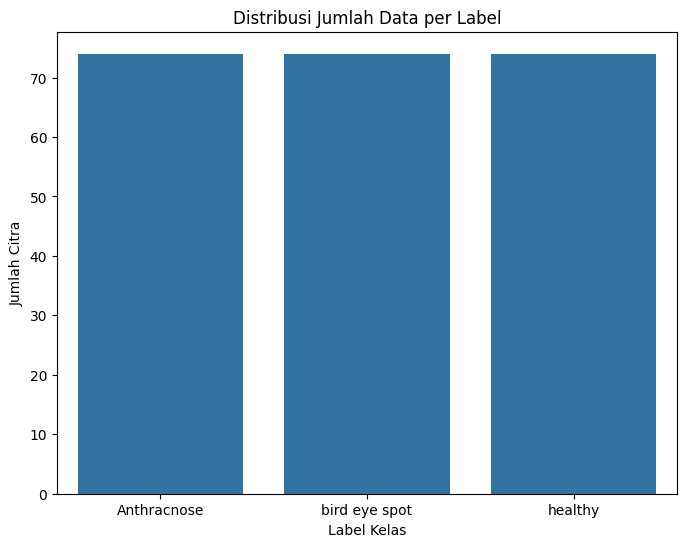

Total jumlah citra dalam dataset: 222
Total jumlah label dalam dataset: 222
Jumlah kelas unik: 3

Jumlah citra per kelas:
Anthracnose      74
bird eye spot    74
healthy          74
Name: count, dtype: int64


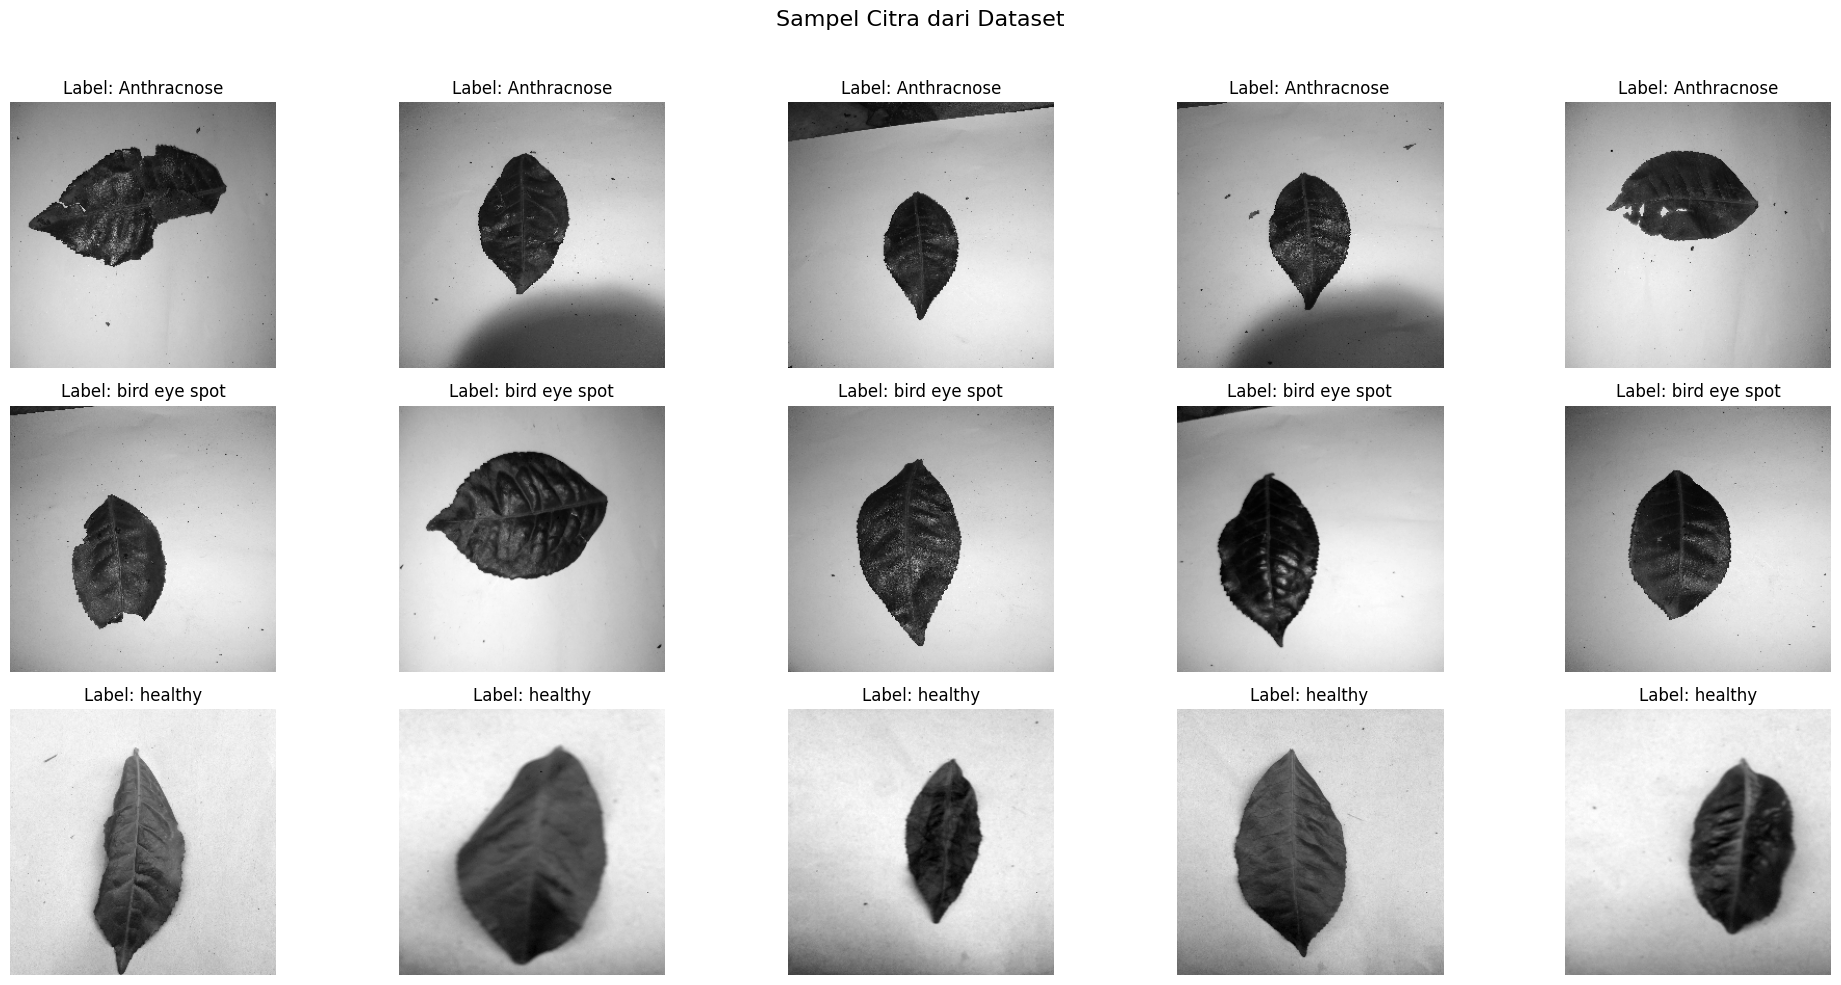

In [104]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'Anthracnose', 'bird eye spot' dan 'healthy'
Anthracnose_indices = np.where(labels == 'Anthracnose')[0]
bird_eye_spot_indices = np.where(labels == 'bird eye spot')[0]
healthy_indices = np.where(labels == 'healthy')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(Anthracnose_indices) >= num_samples_to_show:
    sample_Anthracnose_indices = np.random.choice(Anthracnose_indices, num_samples_to_show, replace=False)
else:
    sample_Anthracnose_indices = Anthracnose_indices

if len(bird_eye_spot_indices) >= num_samples_to_show:
    sample_bird_eye_spot_indices = np.random.choice(bird_eye_spot_indices, num_samples_to_show, replace=False)
else:
    sample_bird_eye_spot_indices = bird_eye_spot_indices

if len(healthy_indices) >= num_samples_to_show:
    sample_healthy_indices = np.random.choice(healthy_indices, num_samples_to_show, replace=False)
else:
    sample_healthy_indices = healthy_indices

# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_Anthracnose_indices, sample_bird_eye_spot_indices, sample_healthy_indices))

# Ubah bagian for loop untuk plotting sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset', fontsize=16)

# Gunakan 3 baris (sesuai jumlah kelas) dan 5 kolom (sesuai num_samples_to_show)
for i, index in enumerate(sample_indices):
    plt.subplot(3, num_samples_to_show, i + 1) 
    plt.imshow(data[index], cmap='gray') 
    plt.title(f"Label: {labels[index]}")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**`show_sample_images`** nampilin satu contoh gambar per kelas, ambil dari index ke-10 di tiap kelas (asal jumlah datanya lebih dari 10). Cuma buat ngecek visual cepat, lihat tiap kelas itu bentuknya kayak apa tanpa harus scroll satu-satu.

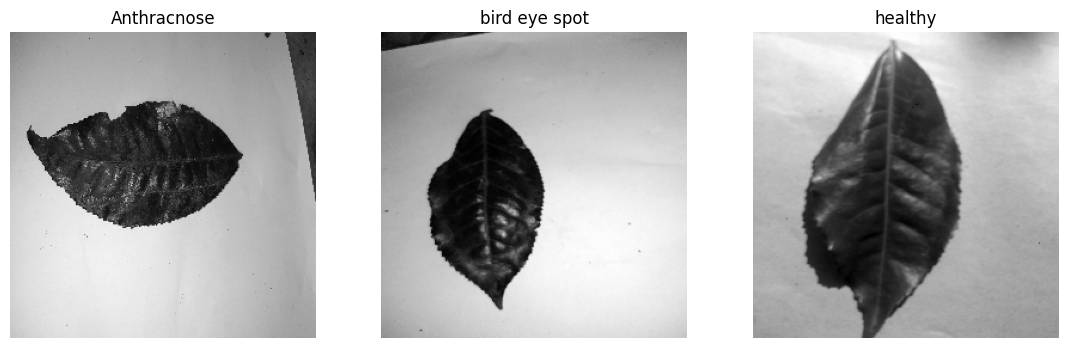

In [105]:
class_names = np.unique(labels)

def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 10:
            plt.subplot(3, 4, i + 1)
            plt.imshow(class_images[10], cmap='gray')
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(data, labels, class_names)

In [106]:
data_augmented = []
labels_augmented = []
print("Data sebelum augmentasi: ", len(data))

Data sebelum augmentasi:  222


Inisialisasi list kosong buat nampung hasil augmentasi data nanti dan print jumlah data awal sebagai pembanding sebelum dan sesudah augmentasi.

In [107]:
def normalize_image(img):
    img_min = np.min(img)
    img_max = np.max(img)
    normalized = (img - img_min) / (img_max - img_min) * 255
    return normalized.astype(np.uint8)

**`normalize_image`** buat normalisasi nilai pixel pakai cara min-max manual (jadi tanpa fungsi bawaan cv2 kayak `cv.normalize`). Caranya ambil nilai pixel paling kecil dan paling besar dari gambar, terus semua pixel diskalakan ulang ke rentang 0-255. Hasil akhirnya dipaksa jadi `uint8` biar formatnya tetap cocok buat diproses GLCM nanti.

**`prepro1_visual`** fungsi utama untuk preprocessing gambar, terdiri dari 3 tahap berurutan: resize ke ukuran 256x256, konversi ke grayscale, dan normalisasi nilai pixel menggunakan metode min-max manual. Fungsi ini mengembalikan ketiga versi gambar (hasil resize, grayscale, dan normalisasi) sekaligus, sehingga setiap tahap preprocessing bisa divisualisasikan secara terpisah untuk keperluan analisis.

Bagian setelah fungsi menjalankan preprocessing ke seluruh dataset menggunakan hanya hasil akhir (normalisasi), lalu disimpan ke `dataPreprocessed` untuk digunakan di tahap ekstraksi fitur selanjutnya. Tiga sampel gambar dipilih secara acak untuk ditampilkan perbandingannya dari gambar asli hingga hasil akhir, sebagai bentuk verifikasi visual bahwa setiap tahap preprocessing berjalan sesuai yang diharapkan.

Menampilkan Grafik Hasil Preprocessing (Sampel Acak):


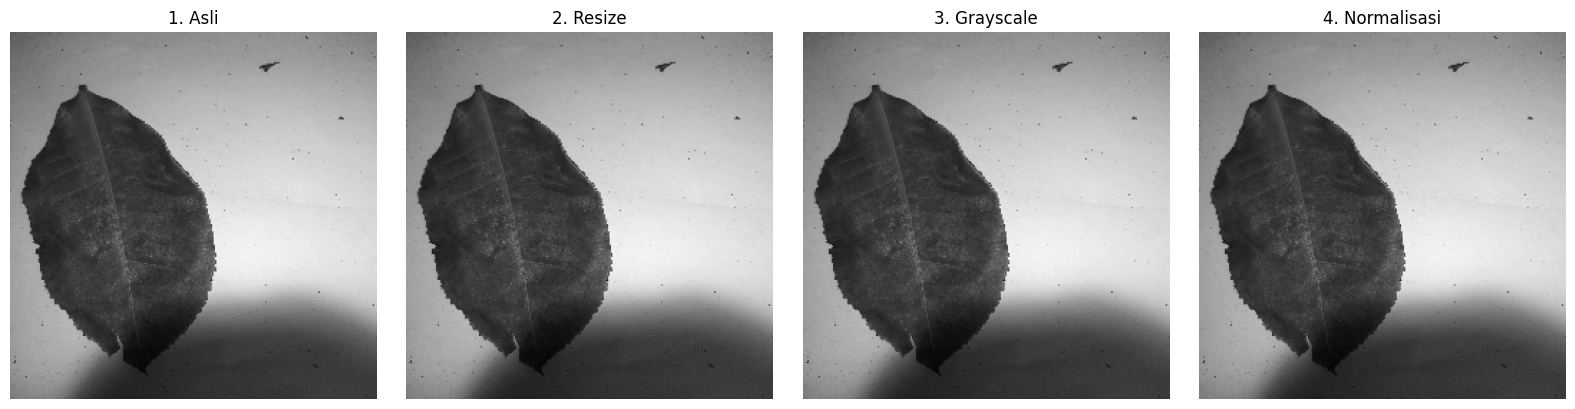

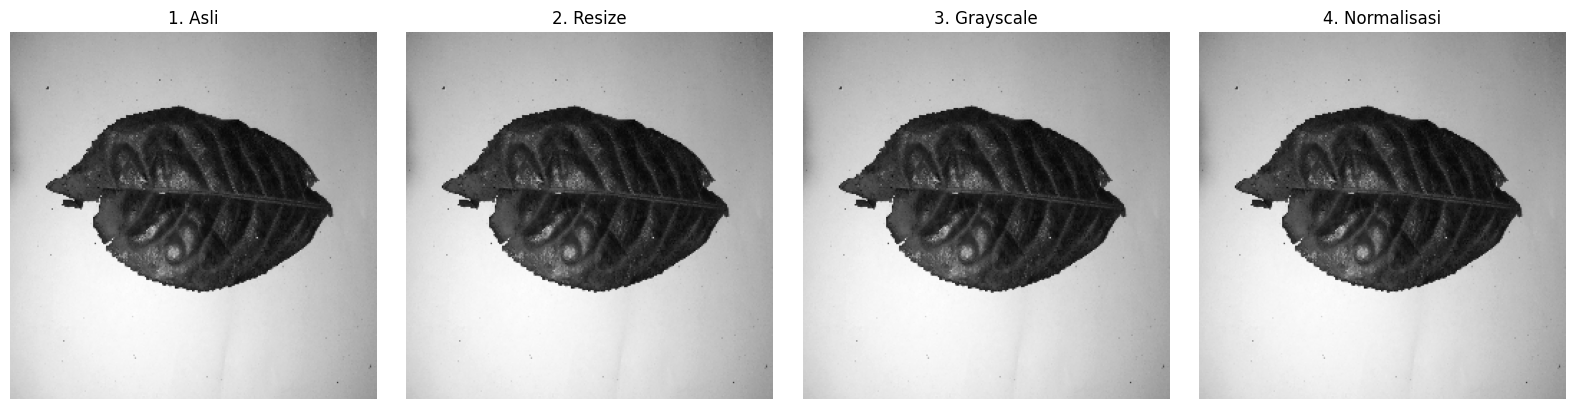

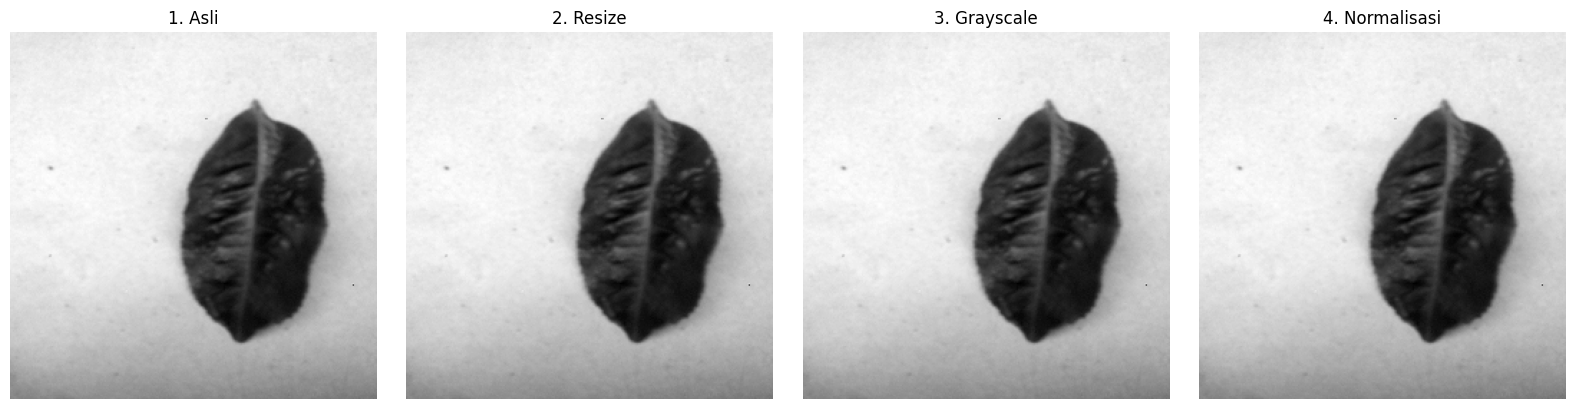

Preprocessing untuk seluruh dataset selesai. Dimensi: (222, 256, 256)


In [108]:
def prepro1_visual(image):
    img_resized = cv.resize(image, (256, 256))
    gray = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY) if len(img_resized.shape) == 3 else img_resized.copy()
    img_min = np.min(gray)
    img_max = np.max(gray)
    normalized = ((gray - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    return img_resized, gray, normalized

dataPreprocessed = []

for i in range(len(data)):
    if data[i] is None: continue

    img_array = np.array(data[i], dtype=np.uint8)
    _, _, final_prep = prepro1_visual(img_array)
    dataPreprocessed.append(final_prep)

dataPreprocessed = np.array(dataPreprocessed)

print("Menampilkan Grafik Hasil Preprocessing (Sampel Acak):")
sample_idx = np.random.choice(len(dataPreprocessed), 3, replace=False)

for idx in sample_idx:
    img_array = np.array(data[idx], dtype=np.uint8)

    resized, gray, normalized = prepro1_visual(img_array)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_array, cmap='gray');   axes[0].set_title("1. Asli");        axes[0].axis('off')
    axes[1].imshow(resized, cmap='gray');     axes[1].set_title("2. Resize");      axes[1].axis('off')
    axes[2].imshow(gray, cmap='gray');        axes[2].set_title("3. Grayscale");   axes[2].axis('off')
    axes[3].imshow(normalized, cmap='gray');  axes[3].set_title("4. Normalisasi"); axes[3].axis('off')
    plt.tight_layout()
    plt.show()

print("Preprocessing untuk seluruh dataset selesai. Dimensi:", dataPreprocessed.shape)

Kumpulan fungsi buat ekstraksi fitur tekstur dari GLCM (Gray-Level Co-occurrence Matrix).

- `glcm` bikin matrix co-occurrence dari gambar berdasarkan sudut yang dipilih (0°, 45°, 90°, atau 135°)
- `correlation`, `dissimilarity`, `homogenity`, `contrast`, `ASM`, `energy` masing-masing ambil satu properti statistik dari matrix GLCM yang udah dibuat
- `entropyGlcm` hitung entropy dari matrix GLCM pakai `scipy.stats.entropy`, beda dari fungsi properti lain yang pakai `graycoprops`

Semua fungsi ini dipanggil bareng-bareng buat ngebentuk fitur tekstur tiap gambar di cell selanjutnya.

In [109]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(m): return graycoprops(m, 'correlation')[0, 0]
def dissimilarity(m): return graycoprops(m, 'dissimilarity')[0, 0]
def homogenity(m): return graycoprops(m, 'homogeneity')[0, 0]
def contrast(m): return graycoprops(m, 'contrast')[0, 0]
def ASM(m): return graycoprops(m, 'ASM')[0, 0]
def energy(m): return graycoprops(m, 'energy')[0, 0]
def entropyGlcm(m): return entropy(m.ravel())

Kumpulan fungsi untuk menghitung matriks GLCM (Gray-Level Co-occurrence Matrix) dan fitur-fitur tekstur yang diturunkan darinya.

- **`glcm`** membentuk matriks co-occurrence dari gambar berdasarkan sudut yang dipilih (0°, 45°, 90°, atau 135°, dikonversi ke radian). Parameter `[3]` menunjukkan jarak antar pixel yang dibandingkan, `256` adalah jumlah level intensitas, `symmetric=True` membuat matriks simetris terhadap arah pasangan pixel, dan `normed=True` menormalkan matriks agar nilai-nilainya berupa probabilitas.
- **`correlation`, `dissimilarity`, `homogenity`, `contrast`, `ASM`, `energy`** masing-masing mengambil satu properti statistik dari matriks GLCM menggunakan `graycoprops`, yang mengukur karakteristik tekstur seperti tingkat kontras, keseragaman, atau hubungan linear antar pixel.
- **`entropyGlcm`** menghitung nilai entropy dari matriks GLCM menggunakan `scipy.stats.entropy`, berbeda dari fungsi-fungsi lain karena tidak menggunakan `graycoprops`. Entropy digunakan untuk mengukur tingkat ketidakteraturan atau kompleksitas tekstur pada gambar.

Seluruh fungsi ini akan dipanggil secara bersamaan pada cell berikutnya untuk membentuk vektor fitur tekstur dari setiap gambar dalam dataset.

In [110]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Menghitung matriks GLCM untuk setiap gambar pada dataset yang sudah dipreprocessing, dilakukan pada 4 sudut sekaligus (0°, 45°, 90°, dan 135°). Hasil matriks GLCM dari setiap sudut disimpan ke dalam list terpisah (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`), yang nantinya akan digunakan untuk menghitung fitur-fitur tekstur pada tahap berikutnya.

In [111]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

Inisialisasi list-list kosong untuk menampung nilai setiap fitur tekstur (kontras, dissimilarity, homogeneity, entropy, ASM, energy, correlation) pada masing-masing sudut (0°, 45°, 90°, 135°). List-list ini akan diisi pada cell berikutnya saat fitur dihitung dari matriks GLCM yang sudah dibentuk sebelumnya.

In [112]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Menghitung nilai fitur correlation dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur correlation mengukur sejauh mana ada hubungan linear antara intensitas pixel yang bertetangga pada arah tersebut.

In [113]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Menghitung nilai fitur contrast dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur contrast mengukur seberapa besar variasi intensitas antara pixel yang bertetangga semakin tinggi nilainya, semakin tajam perbedaan terang-gelap pada tekstur gambar.

In [114]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Menghitung nilai fitur dissimilarity dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur dissimilarity mirip dengan contrast, yaitu mengukur tingkat perbedaan intensitas antar pixel yang bertetangga, namun dengan pembobotan yang bersifat linear terhadap jaraknya.

In [115]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Menghitung nilai fitur homogeneity dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur homogeneity mengukur tingkat keseragaman tekstur semakin tinggi nilainya, semakin merata atau halus distribusi intensitas pixel pada gambar tersebut.

In [116]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Menghitung nilai fitur entropy dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur entropy mengukur tingkat ketidakteraturan atau kompleksitas tekstur semakin tinggi nilainya, semakin acak dan kompleks pola intensitas pixel pada gambar tersebut.

In [117]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Menghitung nilai fitur ASM (Angular Second Moment) dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur ASM mengukur tingkat keseragaman atau homogenitas tekstur berdasarkan kuadrat probabilitas pasangan pixel semakin tinggi nilainya, semakin uniform tekstur gambar tersebut.

In [118]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Menghitung nilai fitur energy dari matriks GLCM tiap gambar, untuk masing-masing sudut (0°, 45°, 90°, 135°), lalu disimpan ke list yang sesuai. Fitur energy merupakan akar kuadrat dari ASM, dan juga mengukur tingkat keseragaman tekstur nilai energy yang tinggi menunjukkan distribusi intensitas pixel yang lebih teratur dan konsisten.

Menggabungkan seluruh fitur tekstur yang telah dihitung (contrast, homogeneity, dissimilarity, entropy, ASM, energy, correlation) dari keempat sudut ke dalam satu tabel data, beserta nama file dan label kelasnya. Tabel ini kemudian disimpan ke dalam file CSV (`hasil_ekstraksi_percobaan_1.csv`) agar bisa digunakan kembali tanpa harus mengulang proses ekstraksi fitur dari awal, lalu dibaca ulang dan ditampilkan sebagai pengecekan hasil akhir.

In [119]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan_1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20220503_143242.jpg,Anthracnose,148.545098,236.040277,191.317126,231.049335,0.362609,0.337870,0.351239,0.339765,...,0.000985,0.000952,0.032002,0.030777,0.031377,0.030853,0.981128,0.969917,0.975599,0.970552
1,IMG_20220503_143328.jpg,Anthracnose,122.885846,169.265913,122.265931,171.528735,0.363709,0.353505,0.378219,0.353541,...,0.001126,0.001043,0.032818,0.032361,0.033559,0.032300,0.980214,0.972792,0.980309,0.972429
2,IMG_20220503_143336.jpg,Anthracnose,175.212669,198.251503,133.984942,215.889458,0.385390,0.358448,0.373642,0.365384,...,0.000903,0.000880,0.030657,0.029346,0.030046,0.029665,0.977359,0.974452,0.982693,0.972179
3,IMG_20220503_143344.jpg,Anthracnose,156.081970,194.514110,129.740349,198.688412,0.387414,0.364673,0.379142,0.368324,...,0.001168,0.001133,0.034836,0.033441,0.034181,0.033655,0.976702,0.970917,0.980570,0.970292
4,IMG_20220503_143352.jpg,Anthracnose,175.923591,267.284352,197.003018,263.706113,0.370940,0.346907,0.359400,0.349997,...,0.001011,0.000979,0.032466,0.031122,0.031795,0.031292,0.978334,0.966969,0.975614,0.967410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,UNADJUSTEDNONRAW_thumb_24b.jpg,healthy,135.916008,149.135825,74.869271,139.662668,0.169541,0.165457,0.183221,0.163919,...,0.001025,0.000946,0.031017,0.030807,0.032008,0.030751,0.982341,0.980665,0.990268,0.981893
218,UNADJUSTEDNONRAW_thumb_24c.jpg,healthy,43.925950,62.150142,38.921829,59.472003,0.238511,0.219395,0.253568,0.220168,...,0.000979,0.000850,0.030050,0.029036,0.031294,0.029148,0.994661,0.992457,0.995265,0.992782
219,UNADJUSTEDNONRAW_thumb_24d.jpg,healthy,54.035248,71.675986,47.396860,68.936947,0.215111,0.201711,0.227858,0.202717,...,0.000869,0.000766,0.028332,0.027634,0.029485,0.027674,0.993489,0.991375,0.994283,0.991704
220,UNADJUSTEDNONRAW_thumb_24e.jpg,healthy,80.061213,92.964998,45.337714,100.050965,0.219153,0.208783,0.239726,0.197965,...,0.000948,0.000803,0.029397,0.028577,0.030791,0.028332,0.992316,0.991096,0.995648,0.990417


Melakukan seleksi fitur untuk menghilangkan redundansi antar fitur GLCM yang terlalu mirip satu sama lain. Caranya dengan menghitung matriks korelasi antar seluruh fitur, lalu menyaring fitur yang memiliki korelasi absolut di atas 0.95 dengan fitur lain jika ditemukan, salah satu dari pasangan fitur tersebut akan dihapus (ditandai `False` pada `columns`) supaya tidak ada informasi yang terlalu berlebihan. Fitur yang sudah lolos seleksi (`x_new`) beserta labelnya (`y`) disiapkan untuk tahap pemodelan, dan divisualisasikan dalam bentuk heatmap untuk memastikan tidak ada lagi pasangan fitur dengan korelasi tinggi yang tersisa.

<Axes: >

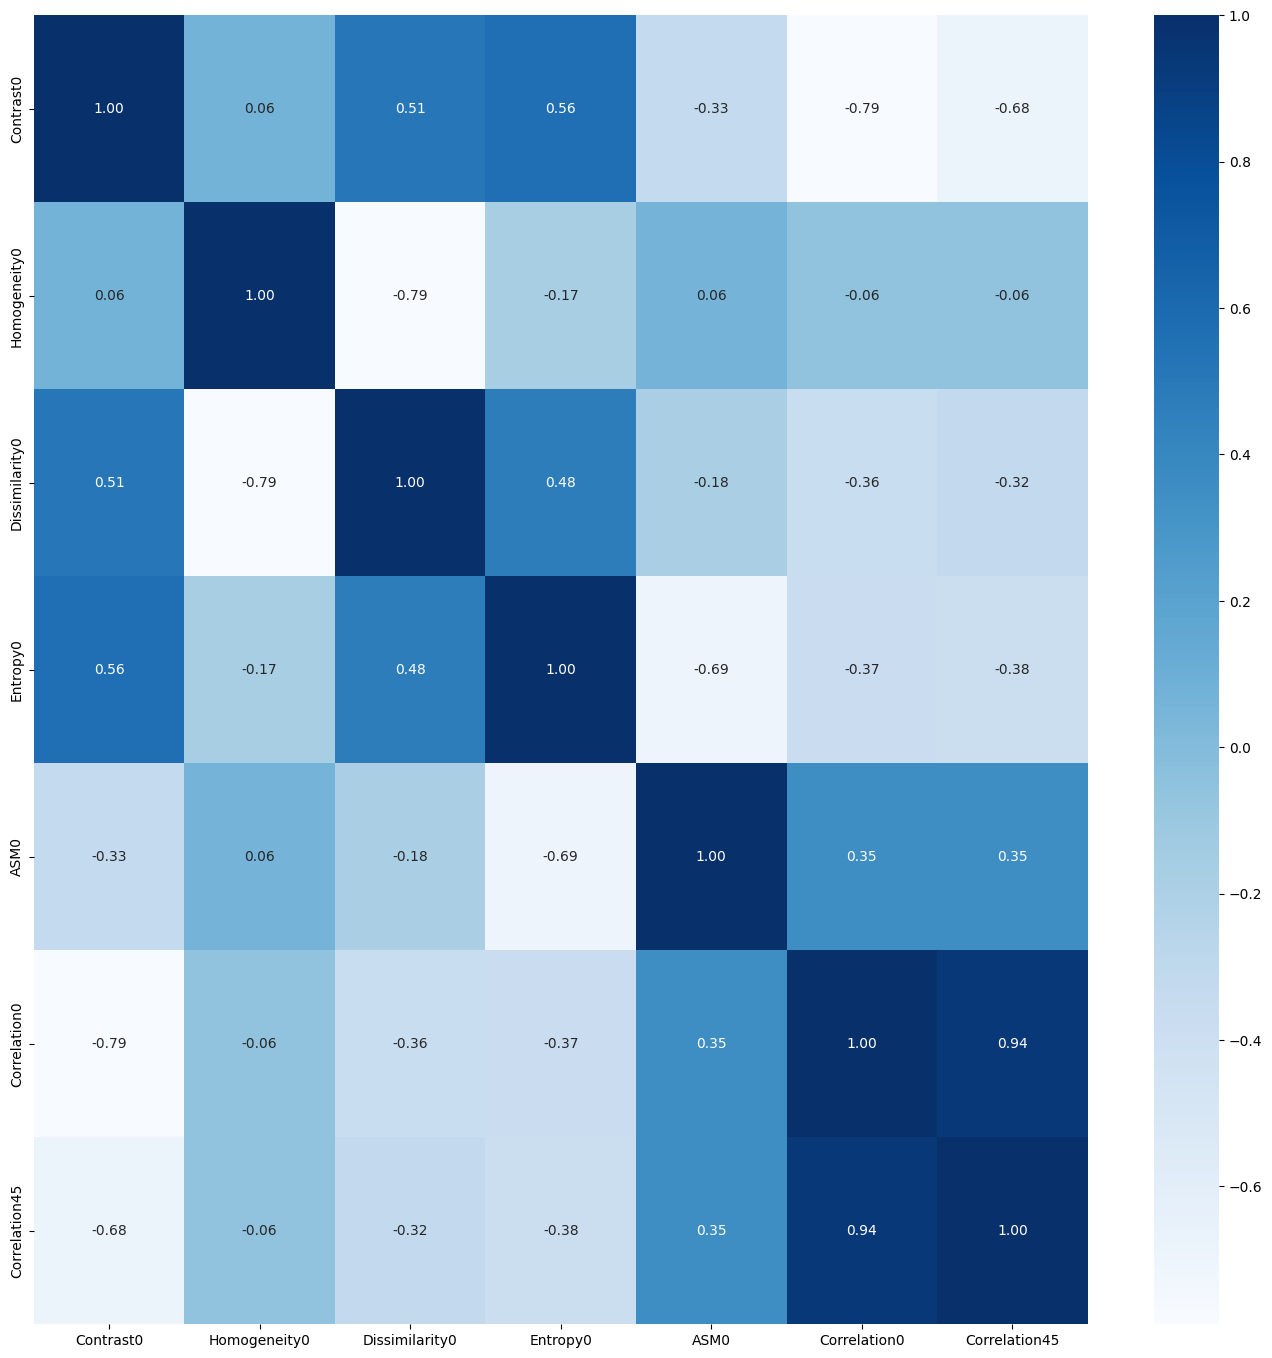

In [120]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [121]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

(177, 7)
(45, 7)


Membagi data menjadi training set dan testing set dengan proporsi 80:20, kemudian melakukan standarisasi (normalisasi mean-std / z-score) pada fitur. Mean dan standar deviasi yang digunakan untuk menormalisasi `X_test` diambil dari `X_train`, bukan dari `X_test` sendiri, untuk mencegah terjadinya *data leakage* karena pada penerapan nyata, statistik dari data testing tidak boleh diketahui saat proses training.

In [122]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

**`generateClassificationReport`** fungsi untuk menampilkan hasil evaluasi model secara ringkas, mencakup classification report (precision, recall, f1-score per kelas), confusion matrix, dan nilai accuracy.

Bagian setelah fungsi mendefinisikan tiga model klasifikasi yang akan digunakan: Random Forest (dengan 5 decision tree), SVM dengan kernel RBF, dan KNN dengan 5 tetangga terdekat. Ketiga model ini akan dilatih dan dibandingkan performanya pada tahap berikutnya.

In [123]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.97      0.93      0.95        61
bird eye spot       0.93      0.96      0.95        54
      healthy       1.00      1.00      1.00        62

     accuracy                           0.97       177
    macro avg       0.96      0.97      0.97       177
 weighted avg       0.97      0.97      0.97       177

[[57  4  0]
 [ 2 52  0]
 [ 0  0 62]]
Accuracy: 0.9661016949152542

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.55      0.46      0.50        13
bird eye spot       0.65      0.75      0.70        20
      healthy       1.00      0.92      0.96        12

     accuracy                           0.71        45
    macro avg       0.73      0.71      0.72        45
 weighted avg       0.71      0.71      0.71        45

[[ 6  7  0]
 [ 5 15  0]
 [ 0  1 11]]
Accuracy: 0.7111111111111111


**Analisis hasil:** Terjadi overfitting accuracy training (96.6%) jauh lebih tinggi dibanding testing (71.1%), selisih lebih dari 25 poin. Model kesulitan membedakan `Anthracnose` dan `bird eye spot` (banyak salah klasifikasi di antara dua kelas ini), sementara `healthy` paling stabil karena teksturnya lebih khas. Kemungkinan penyebab: jumlah data terbatas dan `n_estimators=5` pada Random Forest terlalu kecil sehingga model rentan menghafal data training.

In [124]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.68      0.87      0.76        61
bird eye spot       0.67      0.54      0.60        54
      healthy       1.00      0.90      0.95        62

     accuracy                           0.78       177
    macro avg       0.78      0.77      0.77       177
 weighted avg       0.79      0.78      0.78       177

[[53  8  0]
 [25 29  0]
 [ 0  6 56]]
Accuracy: 0.7796610169491526

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.36      0.38      0.37        13
bird eye spot       0.52      0.55      0.54        20
      healthy       1.00      0.83      0.91        12

     accuracy                           0.58        45
    macro avg       0.63      0.59      0.61        45
 weighted avg       0.60      0.58      0.59        45

[[ 5  8  0]
 [ 9 11  0]
 [ 0  2 10]]
Accuracy: 0.5777777777777777


**Analisis hasil:** Performa model menurun dibanding sebelumnya training accuracy 78%, testing accuracy hanya 57.8%. Gap antara training dan testing masih ada (~20 poin), jadi overfitting belum teratasi, namun training accuracy yang lebih rendah dari sebelumnya (78% vs 96.6%) menunjukkan model jadi *underfit* kemampuannya mengenali pola di data training sendiri pun menurun. Kelas `Anthracnose` dan `bird eye spot` tetap paling sering tertukar satu sama lain, sedangkan `healthy` masih paling mudah dikenali. Perubahan parameter yang dilakukan tampaknya membuat model terlalu sederhana untuk menangkap pola yang ada, bukan menyelesaikan masalah generalisasi.

In [125]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
               precision    recall  f1-score   support

  Anthracnose       0.80      0.79      0.79        61
bird eye spot       0.74      0.72      0.73        54
      healthy       0.94      0.97      0.95        62

     accuracy                           0.83       177
    macro avg       0.82      0.83      0.82       177
 weighted avg       0.83      0.83      0.83       177

[[48 12  1]
 [12 39  3]
 [ 0  2 60]]
Accuracy: 0.8305084745762712

------Testing Set------
               precision    recall  f1-score   support

  Anthracnose       0.36      0.31      0.33        13
bird eye spot       0.57      0.65      0.60        20
      healthy       1.00      0.92      0.96        12

     accuracy                           0.62        45
    macro avg       0.64      0.62      0.63        45
 weighted avg       0.62      0.62      0.62        45

[[ 4  9  0]
 [ 7 13  0]
 [ 0  1 11]]
Accuracy: 0.6222222222222222


**Analisis hasil:** Training accuracy naik ke 83%, testing accuracy 62.2% gap masih sekitar 20 poin, jadi overfitting masih terjadi meski sedikit lebih baik dibanding eksperimen sebelumnya. Pola yang konsisten muncul lagi: `Anthracnose` dan `bird eye spot` paling sering tertukar (recall `Anthracnose` di testing hanya 0.31), sementara `healthy` tetap paling stabil di kedua set. Konsistensi masalah ini di berbagai parameter mengindikasikan akar masalah kemungkinan besar bukan dari pengaturan model, melainkan dari fitur GLCM yang kurang mampu membedakan dua kelas penyakit tersebut secara robust.

**`plot_confusion_matrix`** — fungsi buat gambar confusion matrix dari hasil prediksi model. Tinggal masukin label asli, label prediksi, sama judul plot-nya, nanti otomatis muncul heatmap confusion matrix-nya pakai warna biru.

Grafik Confusion Matrix untuk Ketiga Model:


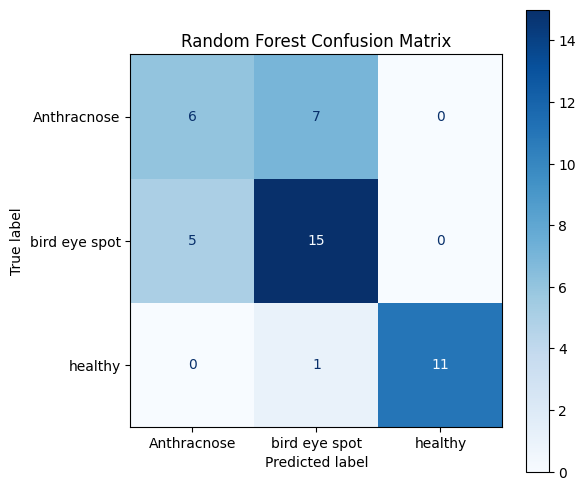

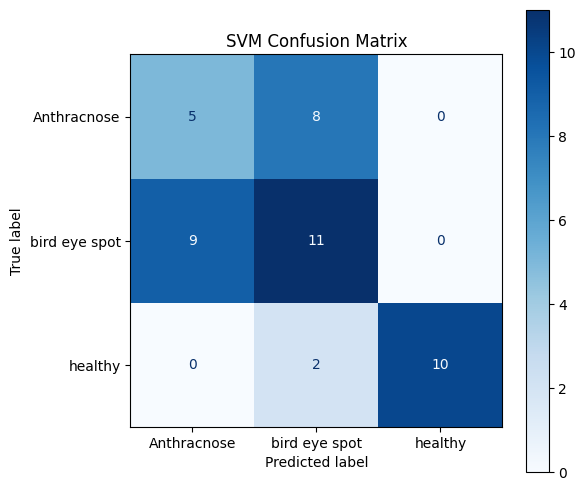

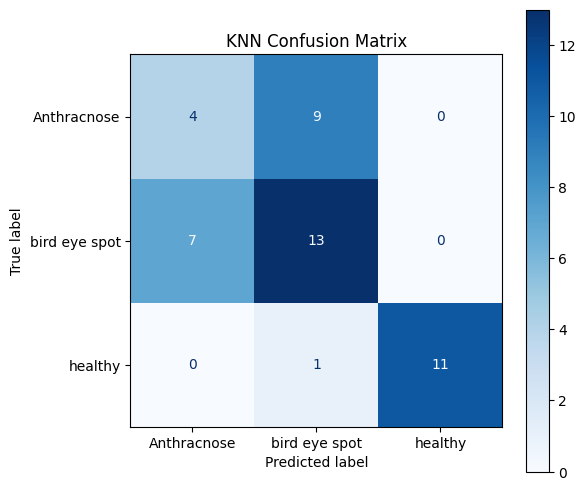

In [126]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title)
    plt.show()

print("Grafik Confusion Matrix untuk Ketiga Model:")
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

**Analisis confusion matrix:** Ketiga model (RF, SVM, KNN) menunjukkan pola kesalahan yang konsisten kebingungan antara kelas `Anthracnose` dan `bird eye spot`, sementara `healthy` hampir selalu benar diklasifikasi. SVM menunjukkan kebingungan paling parah, diikuti KNN, lalu RF. Karena ketiga algoritma dengan pendekatan berbeda mengalami masalah yang sama, kemungkinan besar akar masalahnya bukan pada pemilihan model, melainkan fitur GLCM yang kurang mampu membedakan tekstur kedua penyakit tersebut.